# **🧬📊KIDNEY HEALTH CLASSIFICATION**

This project report is based on a synthetic yet medically realistic dataset of kidney-related health indicators. The dataset is designed to support machine learning tasks such as classification and regression, helping in the evaluation of kidney function and early detection of Chronic Kidney Disease (CKD). By analyzing this data, the project aims to identify key health factors, understand disease patterns, and provide meaningful insights that can assist in improving kidney health assessment and clinical decision-making.

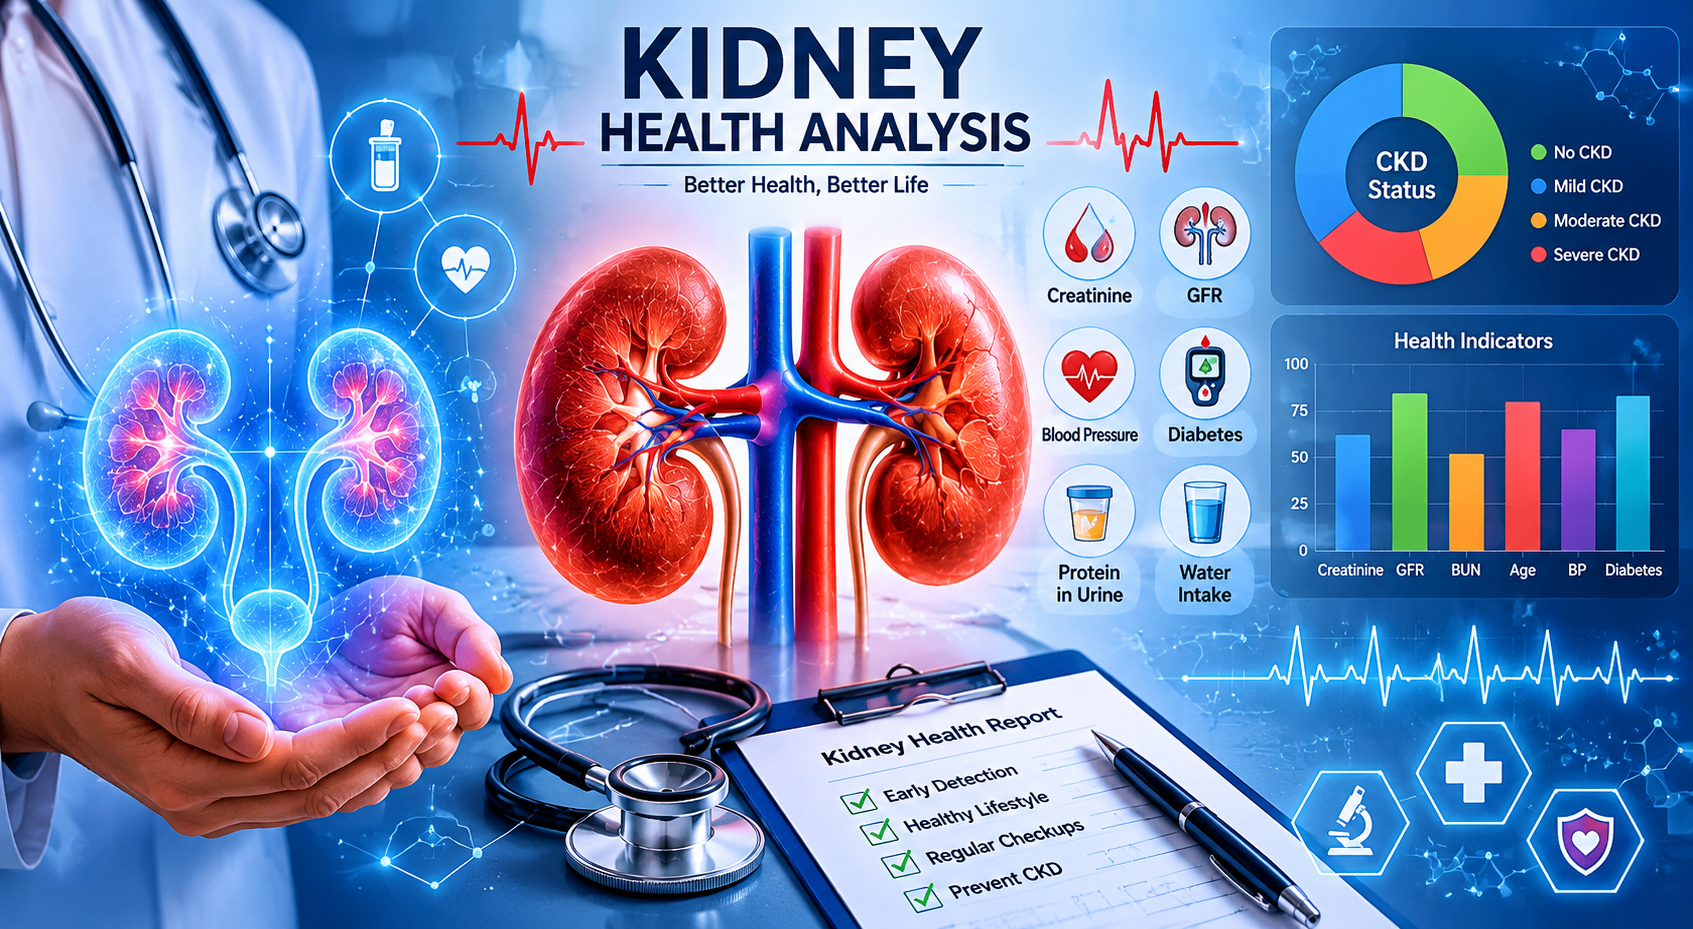

In [73]:
from IPython.display import Image,display
display(Image(filename='/content/sample_data/kidney health.png',width=700))

**TABLE OF CONTENTS**
---

1.IMPORTING LIBRARIES

2.LOADING DATA

3.DATA PREPROCESSING

4.DATA VISUALIZATION

5.GROUPING AND ENCODING ALL THE CATEGORICAL VALUES

6.SEPARATING FEATURES AND TARGET

7.SCALING-TRAIN TEST SPLIT

8.MODEL SELECTION-PERFORMANCE MEASURE

9.CHANGING IMBALANCED DATASET INTO BALANCED DATASET

10.FEATURE SELECTION

11.HYPER PARAMETER TUNING

12.CONCLUSION

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1) IMPORTING SUFFICIENT LIBRARIES**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')


**2) DATASET LOADING**

In [9]:
kh=pd.read_csv("/content/sample_data/kidney_dataset.csv")
kh

,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,NaN,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,ACE Inhibitor,1
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,Diuretic,0
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,ACE Inhibitor,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,ARB,0
...,...,...,...,...,...,...,...,...,...,...,...
4995,4.048737,53.094020,24.964596,1179.120228,1,1,64.910042,2846.781763,3.403640,NaN,1
4996,0.787392,7.598859,94.228637,2029.623102,0,1,49.365980,56.600073,1.759214,ACE Inhibitor,0
4997,1.177967,10.198228,89.099101,2463.843638,0,1,47.207777,88.090385,2.238708,NaN,0
4998,1.189794,12.446732,90.539937,1851.314122,1,0,31.270049,64.837267,3.188672,NaN,0


**3) DATA PREPROCESSING**

In [10]:
kh['Medication'].unique()

array([nan, 'ACE Inhibitor', 'Diuretic', 'ARB'], dtype=object)

In [11]:
kh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   object 
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 429.8+ KB


In [12]:
kh.drop_duplicates

<bound method DataFrame.drop_duplicates of       Creatinine        BUN         GFR  Urine_Output  Diabetes  Hypertension  \
0       0.788803   8.386869  102.161787   1632.649387         0             0   
1       3.413970  53.688796   50.071257    935.540516         1             0   
2       0.647645   7.466540   89.451831   1774.553846         1             1   
3       0.795508  12.516821   99.872180   2360.602980         0             0   
4       0.869010  19.855960   86.110182   1987.750901         0             1   
...          ...        ...         ...           ...       ...           ...   
4995    4.048737  53.094020   24.964596   1179.120228         1             1   
4996    0.787392   7.598859   94.228637   2029.623102         0             1   
4997    1.177967  10.198228   89.099101   2463.843638         0             1   
4998    1.189794  12.446732   90.539937   1851.314122         1             0   
4999    1.000078  11.804883   91.697611   2056.462819         0             0   

            Age  Protein_in_Urine  Water_Intake     Medication  CKD_Status  
0     27.682074        106.700203      1.570370            NaN           0  
1     33.122208        410.008362      3.425287  ACE Inhibitor           1  
2     55.832284        123.336925      1.123301       Diuretic           0  
3     32.391900        116.098870      3.086846  ACE Inhibitor           0  
4     66.689515         55.668760      2.174980            ARB           0  
...         ...               ...           ...            ...         ...  
4995  64.910042       2846.781763      3.403640            NaN           1  
4996  49.365980         56.600073      1.759214  ACE Inhibitor           0  
4997  47.207777         88.090385      2.238708            NaN           0  
4998  31.270049         64.837267      3.188672            NaN           0  
4999  61.782239        134.514375      3.755283  ACE Inhibitor           0  

[5000 rows x 11 columns]>

In [13]:
kh.isna().sum()

,0
Creatinine,0
BUN,0
GFR,0
Urine_Output,0
Diabetes,0
Hypertension,0
Age,0
Protein_in_Urine,0
Water_Intake,0
Medication,2987


In [14]:
#To fill missing value['Medication']
kh['Medication']=kh['Medication'].fillna(kh['Medication'].mode()[0])
kh.isna().sum()

,0
Creatinine,0
BUN,0
GFR,0
Urine_Output,0
Diabetes,0
Hypertension,0
Age,0
Protein_in_Urine,0
Water_Intake,0
Medication,0


In [15]:
kh.dtypes


,0
Creatinine,float64
BUN,float64
GFR,float64
Urine_Output,float64
Diabetes,int64
Hypertension,int64
Age,float64
Protein_in_Urine,float64
Water_Intake,float64
Medication,object


**4) DATA VISUALIZATION**

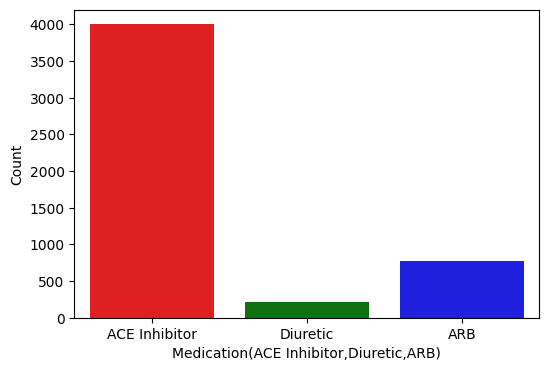

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Medication',data=kh,palette=['red','green','blue'])
plt.xlabel('Medication(ACE Inhibitor,Diuretic,ARB)')
plt.ylabel('Count')
plt.show()

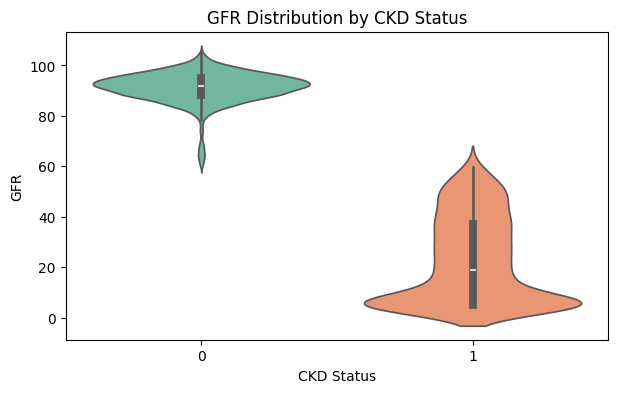

In [65]:
# 1. Violin Plot - GFR Distribution by CKD Status

plt.figure(figsize=(7,4))

sns.violinplot(x='CKD_Status',
               y='GFR',
               data=kh,
               palette='Set2')

plt.title('GFR Distribution by CKD Status')
plt.xlabel('CKD Status')
plt.ylabel('GFR')

plt.show()

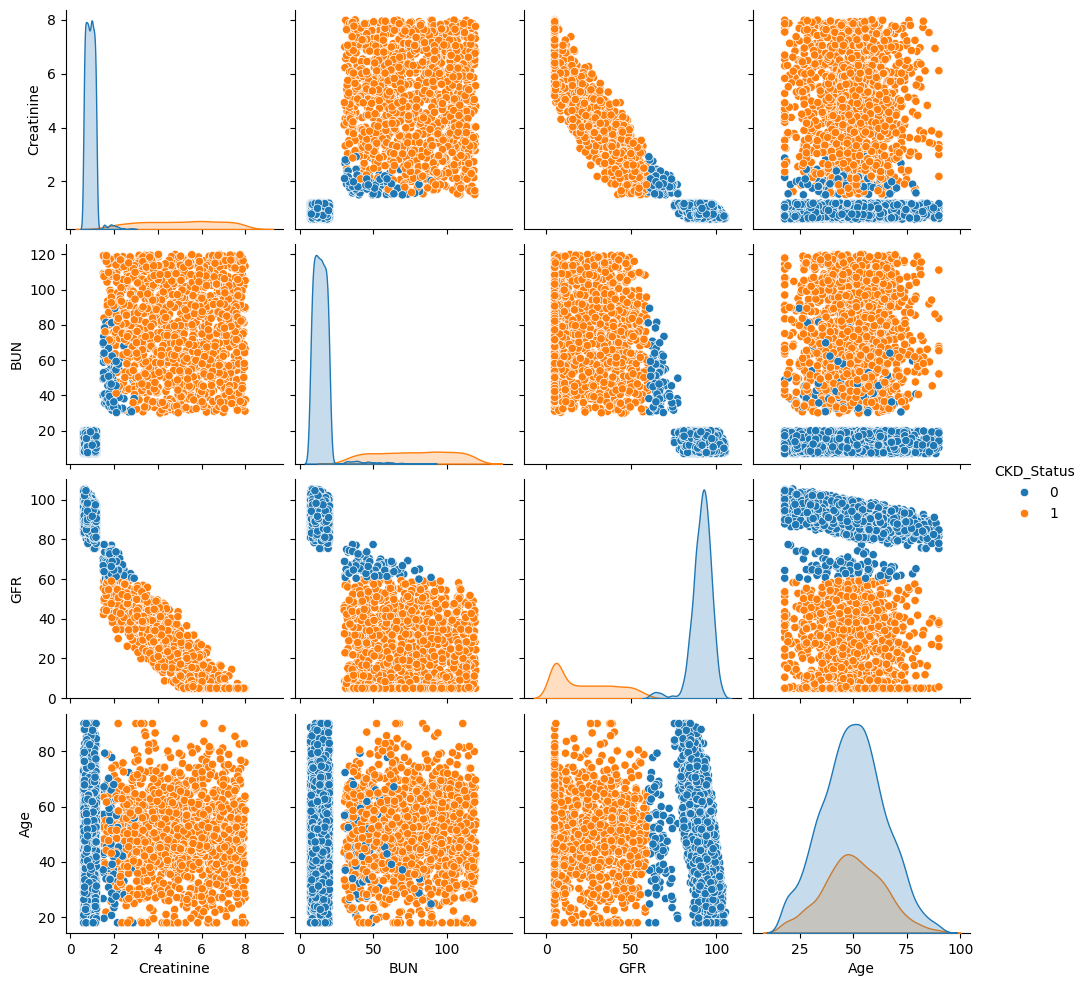

In [66]:
# 2. Pairplot for Important Kidney Features

features = ['Creatinine',
            'BUN',
            'GFR',
            'Age',
            'CKD_Status']

sns.pairplot(kh[features],
             hue='CKD_Status')

plt.show()

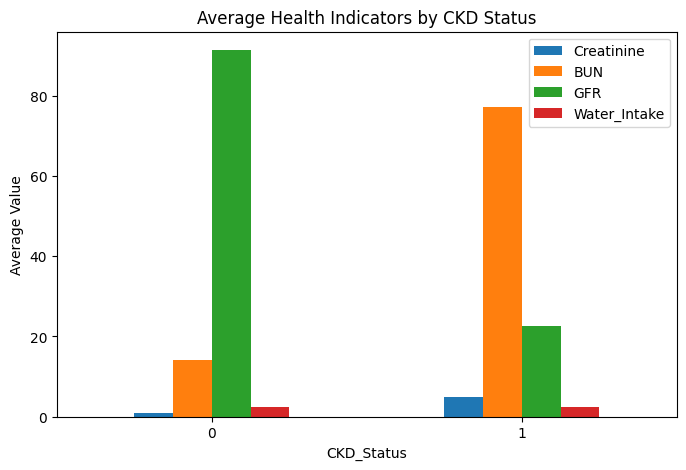

In [67]:
# 3. Average Health Indicators by CKD Status

avg_values = kh.groupby('CKD_Status')[
    ['Creatinine','BUN','GFR','Water_Intake']
].mean()

avg_values.plot(kind='bar',
                figsize=(8,5))

plt.title('Average Health Indicators by CKD Status')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.show()

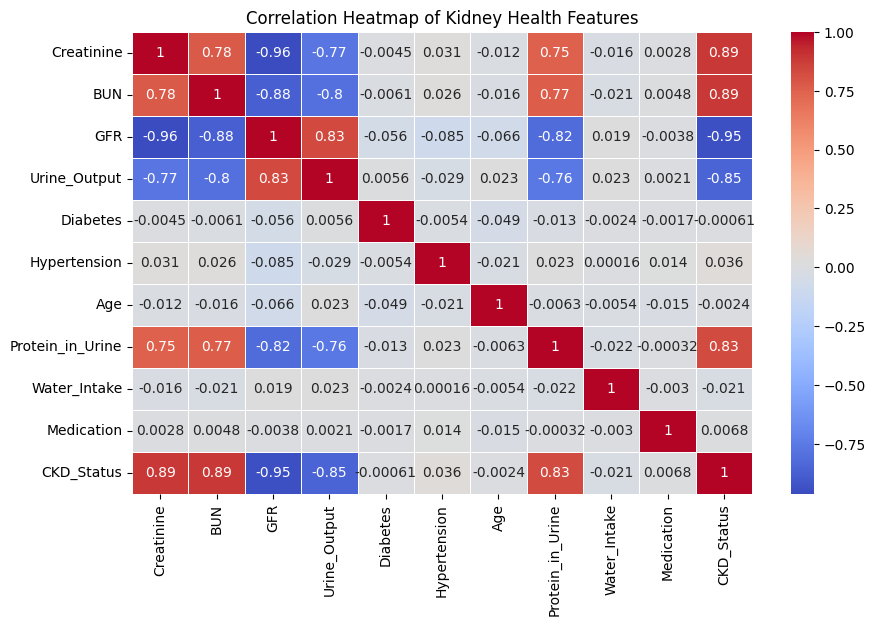

In [62]:
plt.figure(figsize=(10,6))

sns.heatmap(kh.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap of Kidney Health Features')

plt.show()

**5) GROUPING AND ENCODING ALL THE CATEGORICAL COLUMNS**

In [17]:
#To change the object to int or float(numerical values)
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
kh['Medication']=encoder.fit_transform(kh['Medication'])
kh.dtypes


,0
Creatinine,float64
BUN,float64
GFR,float64
Urine_Output,float64
Diabetes,int64
Hypertension,int64
Age,float64
Protein_in_Urine,float64
Water_Intake,float64
Medication,int64


In [18]:
kh

,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,0,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,0,1
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,2,0
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,0,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4995,4.048737,53.094020,24.964596,1179.120228,1,1,64.910042,2846.781763,3.403640,0,1
4996,0.787392,7.598859,94.228637,2029.623102,0,1,49.365980,56.600073,1.759214,0,0
4997,1.177967,10.198228,89.099101,2463.843638,0,1,47.207777,88.090385,2.238708,0,0
4998,1.189794,12.446732,90.539937,1851.314122,1,0,31.270049,64.837267,3.188672,0,0


**6) SEPARATING FEATURES AND TARGET**

In [19]:
x=kh.iloc[:,:-1]
x


,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,0
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,2
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,1
...,...,...,...,...,...,...,...,...,...,...
4995,4.048737,53.094020,24.964596,1179.120228,1,1,64.910042,2846.781763,3.403640,0
4996,0.787392,7.598859,94.228637,2029.623102,0,1,49.365980,56.600073,1.759214,0
4997,1.177967,10.198228,89.099101,2463.843638,0,1,47.207777,88.090385,2.238708,0
4998,1.189794,12.446732,90.539937,1851.314122,1,0,31.270049,64.837267,3.188672,0


In [20]:
y=kh.iloc[:,-1]
y

,CKD_Status
0,0
1,1
2,0
3,0
4,0
...,...
4995,1
4996,0
4997,0
4998,0


**7) SCALING**

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [22]:
scaler.fit(x)

MinMaxScaler()

In [23]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[0.02552092, 0.01221297, 0.96725139, ..., 0.01923176, 0.19002861,
        0.        ],
       [0.38044642, 0.41338509, 0.44868705, ..., 0.12212783, 0.80890521,
        0.        ],
       [0.00643618, 0.00406299, 0.84072302, ..., 0.0248757 , 0.04086789,
        1.        ],
       ...,
       [0.07813631, 0.0282535 , 0.83721158, ..., 0.01291846, 0.41301344,
        0.        ],
       [0.07973528, 0.04816517, 0.85155518, ..., 0.00502993, 0.72996061,
        0.        ],
       [0.05408549, 0.04248127, 0.8630799 , ..., 0.02866761, 0.91900545,
        0.        ]])

**TRAIN TEST SPLIT**

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [25]:
x_train.shape,y_train.shape

((4000, 10), (4000,))

In [26]:
x_test.shape,y_test.shape

((1000, 10), (1000,))

**8) MODEL SELECTION**

In [27]:
knn=KNeighborsClassifier()
sv=SVC(kernel='linear')
nb=GaussianNB()
dt=DecisionTreeClassifier()
rt=RandomForestClassifier(random_state=42)
ad=AdaBoostClassifier()
gd=GradientBoostingClassifier()
xg=XGBClassifier(random_state=1)

**PERFORMANCE MEASURE**

In [28]:
models=[knn,sv,nb,dt,rt,ad,gd,xg]
for model in models:
  print('',model,'')
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  print(classification_report(y_test,y_pred))

 KNeighborsClassifier() 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       721
           1       0.95      0.99      0.97       279

    accuracy                           0.98      1000
   macro avg       0.97      0.99      0.98      1000
weighted avg       0.98      0.98      0.98      1000

 SVC(kernel='linear') 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       721
           1       1.00      1.00      1.00       279

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

 GaussianNB() 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       721
           1       0.95      1.00      0.97       279

    accuracy                           0.98      1000
   macro avg       0.97      0.99      0.98      1000
weighted av

**9) CHANGING IMBALANCED DATASET INTO BALANCED DATASET**

BALANCED:

In [29]:
#this is imbalanced so make it balanced
kh['CKD_Status'].value_counts()

,count
CKD_Status,
0,3685
1,1315


OverSampling:

In [30]:
os=SMOTE(random_state=1)
x_os,y_os=os.fit_resample(x,y)

In [31]:
x_os_scaled=scaler.fit_transform(x_os)
x_os_scaled

array([[0.02552092, 0.01221297, 0.96725139, ..., 0.01923176, 0.19002861,
        0.        ],
       [0.38044642, 0.41338509, 0.44868705, ..., 0.12212783, 0.80890521,
        0.        ],
       [0.00643618, 0.00406299, 0.84072302, ..., 0.0248757 , 0.04086789,
        1.        ],
       ...,
       [0.97391756, 0.84019351, 0.        , ..., 0.68050786, 0.42432067,
        0.        ],
       [0.77955237, 0.41231143, 0.13559239, ..., 0.25936485, 0.07258806,
        0.        ],
       [0.98256875, 0.84185351, 0.        , ..., 0.35616991, 0.33927024,
        0.        ]])

In [32]:
x_os_train,x_os_test,y_os_train,y_os_test=train_test_split(x_os_scaled,y_os,test_size=0.2,random_state=1)

**10) FEATURES SELECTION**

In [33]:
kh.corr()['CKD_Status']

,CKD_Status
Creatinine,0.887267
BUN,0.888944
GFR,-0.947014
Urine_Output,-0.852535
Diabetes,-0.000608
Hypertension,0.036222
Age,-0.002403
Protein_in_Urine,0.828957
Water_Intake,-0.021147
Medication,0.006849


In [34]:
x1=x.drop(['Diabetes','Hypertension','Age','Water_Intake','Medication'],axis=1)

In [35]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y,test_size=.3,random_state=1)

In [36]:
for model in models:
  print(model)
  model.fit(x1_train,y1_train)
  y1_pred=model.predict(x1_test)
  print(classification_report(y1_test,y1_pred))

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1083
           1       0.94      1.00      0.97       417

    accuracy                           0.98      1500
   macro avg       0.97      0.99      0.98      1500
weighted avg       0.98      0.98      0.98      1500

SVC(kernel='linear')
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1083
           1       1.00      1.00      1.00       417

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

GaussianNB()
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1083
           1       0.94      1.00      0.97       417

    accuracy                           0.98      1500
   macro avg       0.97      0.99      0.98      1500
weighted avg     

**11) HYPER PARAMETER TUNING**



In [37]:
from sklearn.model_selection import GridSearchCV
knnparams = {
    'n_neighbors': range(3, 51),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knnhp=GridSearchCV(knn,knnparams,cv=10,scoring='accuracy')
knnhp.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(3, 51),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [38]:
print(knnhp.best_params_)

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


In [39]:
svcparams = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

svchp= GridSearchCV(SVC(),svcparams, cv=5, scoring='accuracy', n_jobs=-1
)
svchp.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [40]:
print(svchp.best_params_)

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [41]:
import numpy as np
nb_params = {
    'var_smoothing': np.logspace(-12, -6, 20)
}

nbhp = GridSearchCV(
    GaussianNB(), nb_params, cv=5, scoring='accuracy'
)
nbhp.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e-12, 2.06913808e-12, 4.28133240e-12, 8.85866790e-12,
       1.83298071e-11, 3.79269019e-11, 7.84759970e-11, 1.62377674e-10,
       3.35981829e-10, 6.95192796e-10, 1.43844989e-09, 2.97635144e-09,
       6.15848211e-09, 1.27427499e-08, 2.63665090e-08, 5.45559478e-08,
       1.12883789e-07, 2.33572147e-07, 4.83293024e-07, 1.00000000e-06])},
             scoring='accuracy')

In [42]:
print(nbhp.best_params_)

{'var_smoothing': np.float64(4.832930238571752e-07)}


In [43]:
dt_params = {
    'max_depth': [None,5,10,20,30],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,5,10],
    'criterion': ['gini', 'entropy']
}

dthp = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dthp.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [44]:
print(dthp.best_params_)

{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [45]:
rf_params = {
    'n_estimators': [100,200,500],
    'max_depth': [None,10,20,40],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,5],
    'max_features': ['sqrt','log2']
}

rfhp = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rfhp.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 40],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='accuracy')

In [46]:
print(rfhp.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [47]:
xgb_params = {
    'n_estimators': [100,200,500],
    'max_depth': [3,6,10],
    'learning_rate': [0.01,0.1,0.3],
    'subsample': [0.7,0.9,1],
    'colsample_bytree': [0.7,0.9,1]
}

xgbhp = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgbhp.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9, 1],
                         'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 6, 10],
                         'n_estimators': [100, 200, 500],
                         'subsample': [0.7, 0.9, 1]},
             scoring='accuracy')

In [48]:
print(xgbhp.best_params_)

{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


In [49]:
ada_base = DecisionTreeClassifier()

ada_params = {
    'estimator__max_depth': [1, 2, 3],
    'n_estimators': [50, 100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

adahp = GridSearchCV(
    AdaBoostClassifier(estimator=ada_base),
    param_grid=ada_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

adahp.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier()),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200, 400]},
             scoring='accuracy')

In [50]:
print(adahp.best_params_)

{'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 50}


In [51]:
gb_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0]
}

gbhp = GridSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gbhp.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.3],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 500],
                         'subsample': [0.7, 0.9, 1.0]},
             scoring='accuracy')

In [52]:
print(gbhp.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


In [53]:
knn1=KNeighborsClassifier(**{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'})
sv1=SVC(**{'C': 1, 'gamma': 'scale', 'kernel': 'linear'})
nb1=GaussianNB(**{'var_smoothing': np.float64(4.832930238571752e-07)})
dt1=DecisionTreeClassifier(**{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2})
rf1=RandomForestClassifier(**{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100})
xgb1=XGBClassifier(**{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7})
gd1=GradientBoostingClassifier(**{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7})

In [57]:
models1=[knn1,sv1,nb1,dt1,rf1,xgb1,gd1]
for model in models1:
  print(model)
  model.fit(x1_train,y1_train)
  y1_pred=model.predict(x1_test)
  print(classification_report(y1_test,y1_pred))

KNeighborsClassifier(metric='manhattan', n_neighbors=4, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1083
           1       0.95      0.99      0.97       417

    accuracy                           0.98      1500
   macro avg       0.97      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500

SVC(C=1, kernel='linear')
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1083
           1       1.00      1.00      1.00       417

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

GaussianNB(var_smoothing=np.float64(4.832930238571752e-07))
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1083
           1       0.94      1.00      0.97       417

    accuracy        

**12) CONCLUSION**

Models such as SVC, Decision Tree Classifier, Random Forest, AdaBoost, Gradient Boosting, and XGBoost Classifier demonstrated strong performance and can be considered the most robust models for this dataset due to their ability to effectively classify Chronic Kidney Disease (CKD) based on kidney health indicators.